In [57]:
import  os  
os.getcwd()

'C:\\Users\\Admin\\ml  models - p'

In [58]:
import  numpy as  np
import  pandas as pd
df= pd.read_csv('C:\\Users\\Admin\\ml  models - p\\insurance - insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


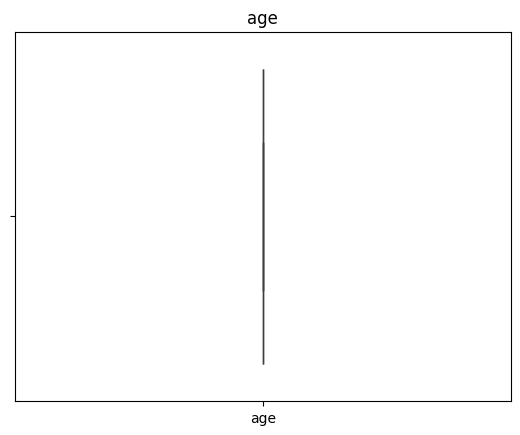

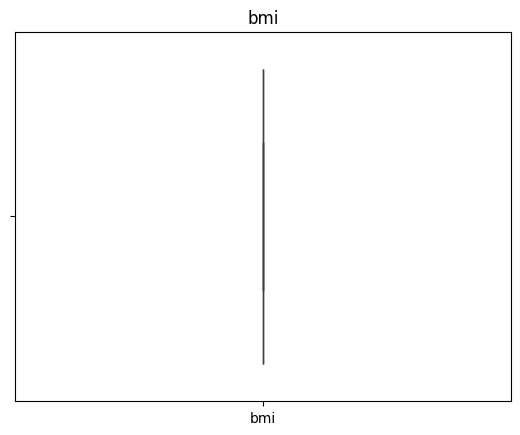

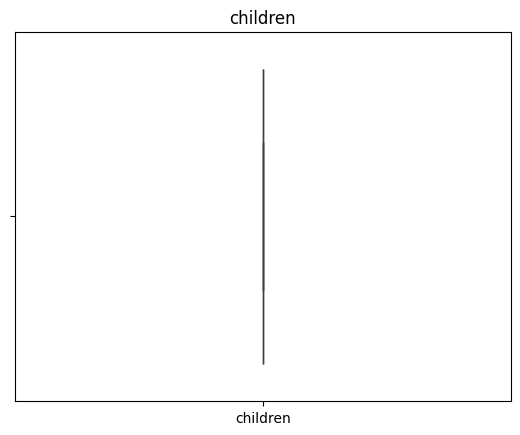

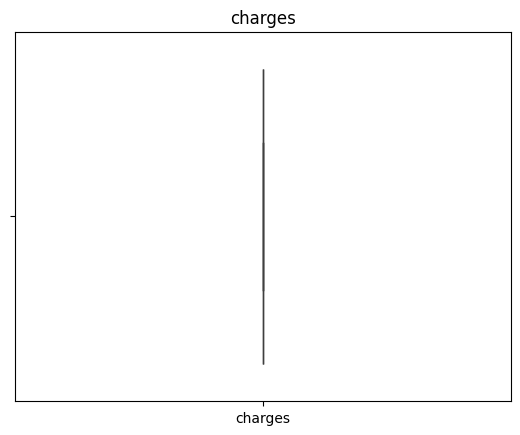

In [59]:
num = df.select_dtypes(include= ['number']).columns.to_list()
num
import  seaborn as  sns  
import  matplotlib.pyplot as  plt 

for  i  in num:
    plt.figure()
    sns.boxplot(x=[i])
    plt.title(i)
    plt.show()
    

In [60]:
from  sklearn.preprocessing  import  LabelEncoder
le =  LabelEncoder() 
df['sex'] =  le.fit_transform(df['sex'])
df['smoker'] =  le.fit_transform(df['smoker'])
df['region'] =  le.fit_transform(df['region']) 


In [61]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [62]:
x= df.drop(columns=['charges'])
y= df['charges']

In [63]:
from  sklearn.model_selection import  train_test_split
x_train , x_test,  y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
from  sklearn.linear_model import  LinearRegression

In [65]:
li =  LinearRegression()

In [66]:
li.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred = li.predict(x_test)

In [68]:
from  sklearn.metrics import r2_score

In [69]:
r2_score(y_test,y_pred)


0.7833463107364539

In [70]:
train_r2_lr = li.score(x_train, y_train)
test_r2_lr  = li.score(x_test, y_test)

print(train_r2_lr ,test_r2_lr)        # train and test scores are close → no overfitting observed


0.7417049283233981 0.7833463107364539


In [71]:
# teacher  show  only  if  overfitting  happen   then  we  digonis  it  like  this  

# Ride  regression model  
from  sklearn.linear_model  import Ridge,Lasso

Ridgere = Ridge(alpha=10)   #  here  alpha  is  penalty  

# train  and  test  score  for  ridge  regression  

Ridgere.fit(x_train,y_train)
x_train_score_ridge  =  Ridgere.score(x_train,y_train)
x_test_score_ridge =  Ridgere.score(x_test,y_test)

print("the  train  score  for  ridge  model  is {} ".format(x_train_score_ridge))
print('the  test   score  for  ridge  model  is {}'.format(x_test_score_ridge))

the  train  score  for  ridge  model  is 0.7398386827259329 
the  test   score  for  ridge  model  is 0.7793155691007558


In [72]:
# lasso  regression model  

In [73]:
lasso = Lasso(alpha= 10 )
lasso.fit(x_train,y_train)

train_score_ls = lasso.score(x_train,y_train)
test_score_ls =  lasso.score(x_test,y_test)

print("the  train  score  for  lasso  model  is {} ".format(train_score_ls))
print('the  test   score  for  lasso  model  is {}'.format(test_score_ls))

the  train  score  for  lasso  model  is 0.7416990458357842 
the  test   score  for  lasso  model  is 0.7831229831162652


In [74]:
# we  use  polynomial  regression  in lineare  regression  when  data  is  non linear  with  smoth parametters  
#  WE  DO  CLEANED  DF  AND  VISUALIZED  IT AND THEN DECIDED WE  USE  POLY IN LINEAR  OR  NOT  

In [75]:
from sklearn.preprocessing  import  PolynomialFeatures

In [79]:
poly  = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x_train)

In [80]:
line2  =  LinearRegression()
line2.fit(x_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
y_pred =  line2.predict(poly.transform(x_test))

In [86]:
r2_score(y_test,y_pred)

0.7717529959070959

In [ ]:
# data ------->>>>>x,y
# x    ------- >>>>>>> binomial  feature show  in visualization  
# x    ------------------->>>>>> then polynomial  regression  
# y   ----------->>>> no change  
# linear regression.fit(x_poly,y)  
# y  predict
# r2_score(y_test,y_pred)

# or  

# with  ai  explaination 

# 1️⃣ data → x, y

# 2️⃣ visualize x vs y
#    └─ if straight line → linear regression
#    └─ if curve (U-shape / bend) → polynomial regression

# 3️⃣ create polynomial features from x
#    └─ x → [x, x², x³ ...]
#    └─ y ❌ no change

# 4️⃣ fit model
#    linear_regression.fit(x_poly, y)

# 5️⃣ predict
#    y_pred = model.predict(x_poly_test)

# 6️⃣ evaluate
#    r2_score(y_test, y_pred)
